# Advanced Analysis and Comparison of Probability Classifiers 

**Name:** Tasneem Rami Qanoa  
**Student ID:** 220210639

## Objective
* To understand the effect of data distribution on the performance of the Gaussian Naive Bayes algorithm. 
* To compare the performance of Naive Bayes with decision trees (studied in Experiment 3) on real-world data. 
* To analyze the confusion matrix to identify model weaknesses.

# 1. Packages and Setup

In [89]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 2. Load data from Titanic dataset

In [90]:
df = pd.read_csv(r"C:\Users\MSI\Downloads\Titanic-Dataset.csv")
display(df.head())
print(df.info())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


# 3. Data Cleanup

In [91]:
#Delete columns that do not affect survival (e.g., PassengerId, Name, Ticket, Cabin) delete data by using drop method.
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
#Fill in the missing values in the Age column using the "Mean" value by using fillna()
df['Age']=df['Age'].fillna(df['Age'].mean())

In [92]:
#i use map to mapping the sex into integer value
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
#fill the null value(nan) with df['Embarked'].mode()[0] using mode to get the most repeated value to fill
#and here i use get dummies becueas we have more than two value in embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) 
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

Divide the data into X (features) and Y (survived column) columns
in an 80:20 ratio

In [93]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Task 1: var_smoothing Analysis 
**Default var_smoothing (1e-9)**

In [94]:
# 1. Train the model with the default var_smoothing value (1e-9)
model_default = GaussianNB()
model_default.fit(X_train, y_train)
# Calculate accuracy for the default model
acc_default = accuracy_score(y_test, model_default.predict(X_test))

**Large var_smoothing (1e-1)**

In [95]:
# 2. Train the model with a large smoothing value (1e-1) as required 
model_smoothed = GaussianNB(var_smoothing=1e-1)
model_smoothed.fit(X_train, y_train)
# Calculate accuracy for the smoothed model
acc_smoothed = accuracy_score(y_test, model_smoothed.predict(X_test))

In [96]:
print(f"Accuracy with default smoothing: {acc_default}")
print(f"Accuracy with 1e-1 smoothing: {acc_smoothed}")

Accuracy with default smoothing: 0.770949720670391
Accuracy with 1e-1 smoothing: 0.6368715083798883


* The var_smoothing parameter helps make the model more stable by adding a small value to the variance of each feature.
* This value is taken as a portion of the largest variance in the dataset.
* When we increase var_smoothing, it works like a regularizer—it makes the Gaussian distributions wider and reduces the model’s sensitivity to small changes or noise in the data.
* This helps prevent overfitting and improves the model’s generalization.
* **Increasing var_smoothing makes the model less sensitive to variance.
This can reduce overfitting but may lower accuracy.**

# Task 2: Adding Noise to Age 

Add noise to the Age column (add large random numbers to some rows). 

In [97]:
df_noisy = df.copy()
# Add noise to 15% of rows
indices = df_noisy.sample(frac=0.15, random_state=42).index
df_noisy.loc[indices, 'Age'] = np.random.randint(100, 500, size=len(indices))

# Task 3: Modeling 

In [98]:
# Train the GaussianNB model on the training data. 
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_nb = gnb.predict(X_test)   

# Train the DecisionTreeClassifier model
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Task 4: Quantitative Evaluation

In [105]:
from sklearn.metrics import confusion_matrix

# Extract the accuracy of both models on the test data.
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# Extract the confusion matrix for each model using sklearn.metrics
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("NB Confusion Matrix:\n", cm_nb)
print("DT Confusion Matrix:\n", cm_dt)

Naive Bayes Accuracy: 0.770949720670391
Decision Tree Accuracy: 0.7988826815642458
NB Confusion Matrix:
 [[84 21]
 [20 54]]
DT Confusion Matrix:
 [[95 10]
 [26 48]]


# Task 5: Probability Distribution 

In [100]:
probs = gnb.predict_proba(X_test[:5])
print("Survival Probabilities for first 5 test samples (GNB):")
print(probs)

Survival Probabilities for first 5 test samples (GNB):
[[0.89298365 0.10701635]
 [0.9176673  0.0823327 ]
 [0.95263047 0.04736953]
 [0.09662692 0.90337308]
 [0.15120529 0.84879471]]


# answers to questions:Q2 & Q5 & Q6 & Q7

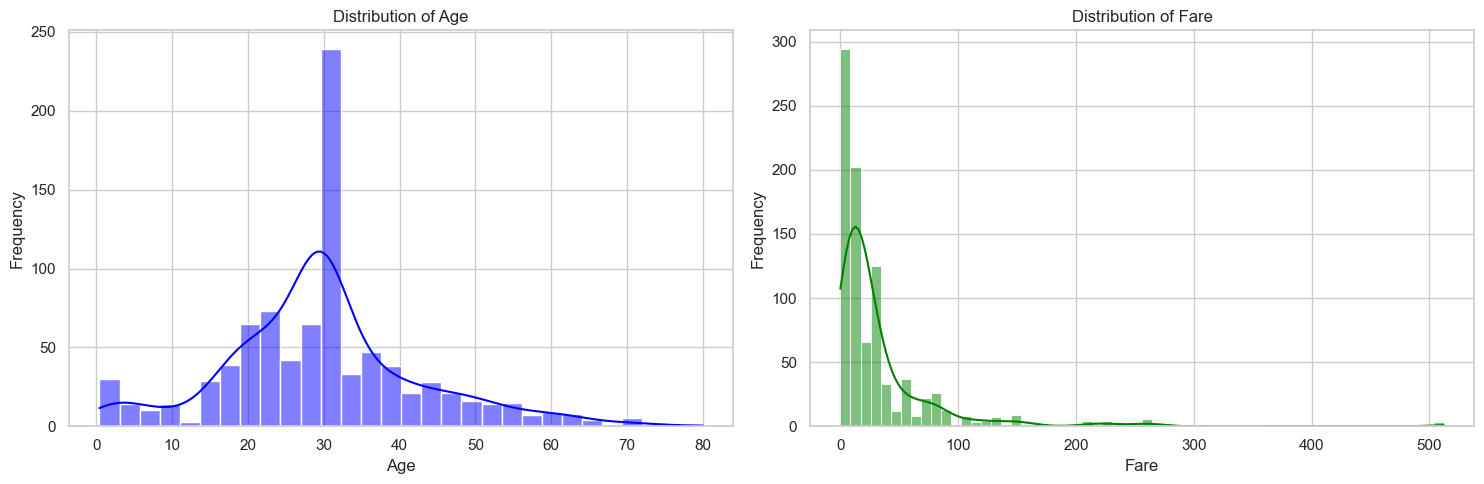

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Histogram for Age
sns.histplot(df['Age'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Plot Histogram for Fare
sns.histplot(df['Fare'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

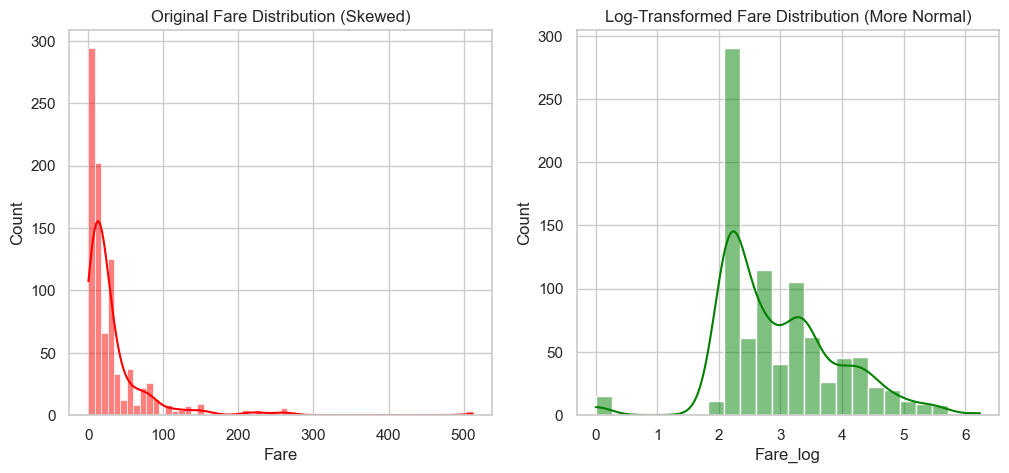

Accuracy with Original Fare: 0.7709
Accuracy with Log-Transformed Fare: 0.7598


In [102]:
# 1. Visualization: Original vs Log-Transformed Fare
plt.figure(figsize=(12, 5))

# Plot Original Fare
plt.subplot(1, 2, 1)
sns.histplot(df['Fare'], kde=True, color='red')
plt.title('Original Fare Distribution (Skewed)')

# Apply Log Transformation
# We use log1p (log(1+x)) to handle any zero-fare entries safely
df['Fare_log'] = np.log1p(df['Fare'])

# Plot Log-Transformed Fare
plt.subplot(1, 2, 2)
sns.histplot(df['Fare_log'], kde=True, color='green')
plt.title('Log-Transformed Fare Distribution (More Normal)')

plt.show()

# 2. Retraining and Comparison
# Assume X contains other features and we are comparing Fare vs Fare_log

# Baseline: Using Original Fare
X_orig = df.drop(['Survived', 'Fare_log'], axis=1) 
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X_orig, y, test_size=0.2, random_state=42)

model_orig = GaussianNB()
model_orig.fit(X_train, y_train)
acc_orig = accuracy_score(y_test, model_orig.predict(X_test))

# Transformed: Using Log Fare
X_log = df.drop(['Survived', 'Fare'], axis=1) # Replace original Fare with Fare_log
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_log, y, test_size=0.2, random_state=42)

model_log = GaussianNB()
model_log.fit(X_train_l, y_train_l)
acc_log = accuracy_score(y_test_l, model_log.predict(X_test_l))

print(f"Accuracy with Original Fare: {acc_orig:.4f}")
print(f"Accuracy with Log-Transformed Fare: {acc_log:.4f}")

In [103]:
from sklearn.preprocessing import LabelEncoder

# 1. Create the Feature Interaction: Combine Sex and Pclass
# Example: 'male' and '1' becomes 'male_1'
df['Sex_Pclass'] = df['Sex'].astype(str) + "_" + df['Pclass'].astype(str)

# 2. Encoding for GaussianNB
# Since GaussianNB requires numeric data, we encode our categorical columns
le = LabelEncoder()
df_encoded = df.copy()

# Encode individual features for the original model
df_encoded['Sex'] = le.fit_transform(df['Sex'])
# Encode the hybrid feature for the new model
df_encoded['Sex_Pclass'] = le.fit_transform(df['Sex_Pclass'])

# 3. Define feature sets
# Original: Uses independent features
features_orig = ['Age', 'Sex', 'Pclass', 'Fare'] 
# Hybrid: Uses the interaction feature instead of individual Sex/Pclass
features_hybrid = ['Age', 'Fare', 'Sex_Pclass']

y = df_encoded['Survived']

# 4. Evaluate Original Model
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(df_encoded[features_orig], y, test_size=0.2, random_state=42)
gnb_orig = GaussianNB().fit(X_train_o, y_train_o)
acc_orig = accuracy_score(y_test_o, gnb_orig.predict(X_test_o))

# 5. Evaluate Hybrid Model
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(df_encoded[features_hybrid], y, test_size=0.2, random_state=42)
gnb_hybrid = GaussianNB().fit(X_train_h, y_train_h)
acc_hybrid = accuracy_score(y_test_h, gnb_hybrid.predict(X_test_h))

print(f"Original GNB Accuracy: {acc_orig:.4f}")
print(f"Hybrid GNB Accuracy: {acc_hybrid:.4f}")

Original GNB Accuracy: 0.7598
Hybrid GNB Accuracy: 0.7821


In [104]:
y_pred_gnb = gnb.predict(X_test)
# Assuming y_test are actual values and y_pred_gnb are Naive Bayes predictions
cm_gnb = confusion_matrix(y_test, y_pred_gnb)

# Extracting False Positives (Predicted Survive, but Actually Drowned)
# Matrix structure: [[TN, FP], [FN, TP]]
false_positives = cm_gnb[0, 1]
false_negatives = cm_gnb[1, 0]

print(f"Number of False Positives: {false_positives}")
print(f"Number of False Negatives: {false_negatives}")

Number of False Positives: 21
Number of False Negatives: 20
